# 09. 反復法と前処理 — 大規模な $Ax = b$ をどう解くか(付録)

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 4. Gauss-Seidel |
| Applied | 5. GMRES 〜 7. 前処理 |
| Advanced | 8. Advanced Notes |

## 1. Big Picture

06 章では直接法(LU)と、対称正定値向けの **共役勾配法(CG)** を見ました。
本章はその間を埋める **定常反復法**(Jacobi・Gauss-Seidel)と、
非対称行列向けの **GMRES**、そして反復法を速くする **前処理** を扱います。

共通する発想は 06 章と同じ:

> 巨大で疎な $A$ では $O(n^3)$ の直接法は使えない。
> **行列ベクトル積 $Av$ だけ** を繰り返して解に近づく。

```{admonition} 核心 — ひとことで
:class: tip
**巨大で疎な $Ax=b$ は、行列ベクトル積 $Av$ だけを繰り返して解に「近づける」。**
収束の速さは条件数 $\kappa$ が握り、**前処理** $M^{-1}A$ で $\kappa$ を下げれば反復回数が激減する。
対称正定値なら CG、非対称なら GMRES — どれも Krylov 部分空間 $\mathrm{span}\{b,Ab,A^2b,\dots\}$ の中で最良解を探す。
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import cg, gmres, spilu, LinearOperator

from la_book import algebra, plotting

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)

## 2. Problem — 定常反復法のアイデア

$A$ を「対角 $D$ + 残り $R$」に分けます($A = D + R$)。$Ax = b$ は $Dx = b - Rx$ と書け、
これを更新式に読み替えると **Jacobi 法**:

$$
x^{(k+1)} = D^{-1}\left(b - R\, x^{(k)}\right)
$$

「いまの推定 $x^{(k)}$ を右辺に入れて、次の推定を作る」を繰り返すだけ。
$A$ が **対角優位**(各行で対角成分が他の和より大きい)なら収束します。

## 3. Jacobi 法

In [2]:
# A strictly diagonally dominant system: Jacobi converges.
A = np.array([[4.0, 1.0, 0.0], [1.0, 5.0, 1.0], [0.0, 1.0, 3.0]])
b = np.array([1.0, 2.0, 3.0])
x_jac, res_jac = algebra.jacobi(A, b, n_iter=40, return_history=True)
print("Jacobi solution:", x_jac, " (direct:", np.linalg.solve(A, b), ")")

Jacobi solution: [0.2075 0.1698 0.9434]  (direct: [0.2075 0.1698 0.9434] )


## 4. Gauss-Seidel 法 — 「できたてを使う」

Jacobi は 1 スイープ中ずっと古い $x^{(k)}$ を使います。
**Gauss-Seidel** は、更新した成分をその場で次の成分の計算に使います。
たいてい Jacobi の約 2 倍速く収束します。

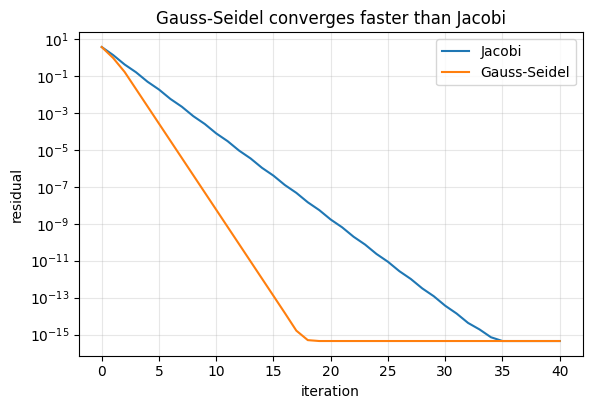

Gauss-Seidel solution: [0.2075 0.1698 0.9434]


In [3]:
# Gauss-Seidel vs Jacobi convergence on the same system.
x_gs, res_gs = algebra.gauss_seidel(A, b, n_iter=40, return_history=True)
plotting.plot_convergence({"Jacobi": res_jac, "Gauss-Seidel": res_gs}, ylabel="residual")
plt.title("Gauss-Seidel converges faster than Jacobi")
plt.show()
print("Gauss-Seidel solution:", x_gs)

## 5. GMRES — 非対称行列のための反復法

CG は **対称正定値** 専用でした(06 章)。
非対称な $A$ には **GMRES**(一般化最小残差法)を使います。
Krylov 部分空間 $\mathrm{span}\{b, Ab, A^2 b, \dots\}$ の中で残差を最小化していく方法で、
SciPy に実装があります。

GMRES converged (info=0), final residual = 1.91e-07


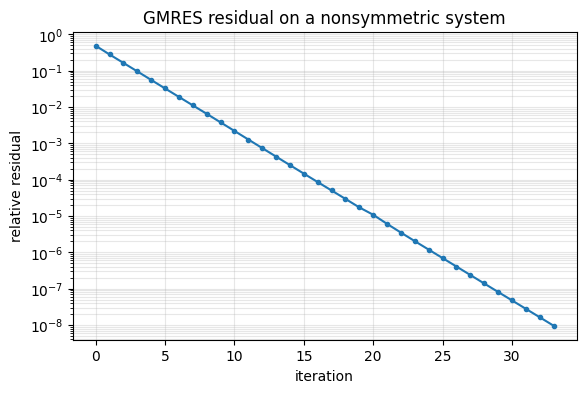

In [4]:
# A nonsymmetric sparse system solved with GMRES.
n = 400
main = 4.0 * np.ones(n)
A_ns = sp.diags([main, -1 * np.ones(n - 1), -2 * np.ones(n - 1)], [0, -1, 1], format="csr")
b_ns = rng.standard_normal(n)

res_hist = []
x_gmres, info = gmres(A_ns, b_ns, rtol=1e-8, callback=lambda r: res_hist.append(r),
                      callback_type="pr_norm")
print(f"GMRES converged (info={info}), final residual = {np.linalg.norm(A_ns @ x_gmres - b_ns):.2e}")
plt.figure(figsize=(6.5, 4))
plt.semilogy(res_hist, "o-", ms=3)
plt.xlabel("iteration"); plt.ylabel("relative residual"); plt.grid(alpha=0.3, which="both")
plt.title("GMRES residual on a nonsymmetric system")
plt.show()

## 6. 収束は条件数に効く(06 章の復習)

反復法の収束速度は **条件数** に支配されます(06 章)。
条件数が悪いほど CG/GMRES の反復回数が増えます。SPD 系で確かめます。

In [5]:
# Worse conditioning -> CG needs more iterations.
def make_spd(n, cond):
    Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
    eig = np.linspace(1, cond, n)
    return Q @ np.diag(eig) @ Q.T

for cond in [10, 100, 1000]:
    A_spd = make_spd(80, cond)
    b_spd = rng.standard_normal(80)
    _, res = algebra.conjugate_gradient(A_spd, b_spd, tol=1e-8)
    print(f"cond = {cond:>5}: CG iterations to 1e-8 = {len(res) - 1}")

cond =    10: CG iterations to 1e-8 = 30
cond =   100: CG iterations to 1e-8 = 52
cond =  1000: CG iterations to 1e-8 = 58


## 7. 前処理 — 問題を「解きやすく」変形する

前処理は $Ax = b$ を、解は同じだが **条件数の小さい** 等価な系
$M^{-1}A x = M^{-1}b$ に変換します($M \approx A$ かつ $M^{-1}$ が安く作れるもの)。
反復回数が劇的に減ります。不完全 LU(ILU)前処理付き GMRES で効果を見ます。

In [6]:
# Incomplete-LU preconditioning slashes the GMRES iteration count.
ilu = spilu(A_ns.tocsc())
M = LinearOperator(A_ns.shape, ilu.solve)

for name, kw in [("no preconditioner", {}), ("ILU preconditioned", {"M": M})]:
    hist = []
    x, info = gmres(A_ns, b_ns, rtol=1e-8, callback=lambda r: hist.append(r),
                    callback_type="pr_norm", **kw)
    print(f"{name:22s}: {len(hist)} iterations")

no preconditioner     : 34 iterations
ILU preconditioned    : 1 iterations


前処理ありでは数反復で収束します。
実務の大規模シミュレーション(偏微分方程式など)では、
**良い前処理の設計こそが本丸** で、反復法そのものより重要なこともあります。

```{admonition} 実社会では
:class: important
大規模シミュレーションの計算時間は、ほぼ「反復法 × 前処理」で決まります。

- 流体・構造・電磁場（PDE）：数百万〜数億次元の疎な系を CG / GMRES + 前処理で解く。
- 機械学習：大規模ロジスティック回帰・ガウス過程の推論も前処理付き反復法が要。
- レンダリング・最適化：疎な線形系を毎フレーム解く。

「どんな前処理 $M$ を設計するか」が性能の本丸で、反復法そのものより重要なことも多いです。
```

## 8. まとめ

- **Jacobi / Gauss-Seidel**: $A = D + R$ の分割による定常反復。対角優位なら収束。GS は約 2 倍速い。
- **GMRES**: 非対称行列向けの Krylov 法(CG の非対称版)。
- 収束速度は **条件数** に支配される(06 章)。
- **前処理** $M^{-1}A$ は条件数を下げ、反復回数を激減させる。大規模問題の主戦場。

## 9. Exercises

1. 対角優位でない行列(対角成分を小さく)で Jacobi が発散することを確認せよ。
2. Gauss-Seidel が Jacobi の何倍速いか、残差が $10^{-6}$ を切る反復回数で比較せよ。
3. GMRES の `restart` パラメータを変え、収束とメモリのトレードオフを観察せよ。
4. ILU 前処理ありとなしで GMRES の反復回数を、行列サイズ $n$ を変えながら比較せよ。
5. (発展)2 次元ポアソン方程式を 5 点差分で離散化し、CG + ILU で解いてみよ。

## 反復ソルバの収束比較(インタラクティブ)

同じ SPD 系を Jacobi・Gauss-Seidel・共役勾配で解いたときの残差を反復ごとに対数軸で重ねる。CG が他を桁違いに引き離して速いことが一目で分かる。

In [7]:
import plotly.io as pio
from la_book import plotting as viz

pio.renderers.default = "plotly_mimetype+notebook_connected"
fig = viz.plotly_iterative_convergence()
fig.show()